# Loan Approval Prediction — Credit Risk Dataset
### Comparing SVC · Logistic Regression · Random Forest · Gradient Boosting · XGBoost · LightGBM


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, f1_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('./credit_risk_dataset.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.73,6.35,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.85,61983.12,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.79,4.14,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.37,6322.09,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.01,3.24,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.22,0.41,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.17,0.11,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.80,4.06,2.00,3.00,4.00,8.00,30.00


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct}).query('Count > 0')


,Count,Percentage (%)
person_emp_length,895,2.75
loan_int_rate,3116,9.56


## 2. Exploratory Data Analysis
> **Note on missing values:** `person_emp_length` (2.7%) and `loan_int_rate` (9.6%) have missing entries.
> These will be imputed with the **training-set median** inside the pipeline to prevent data leakage.


### 2.1 Class Distribution

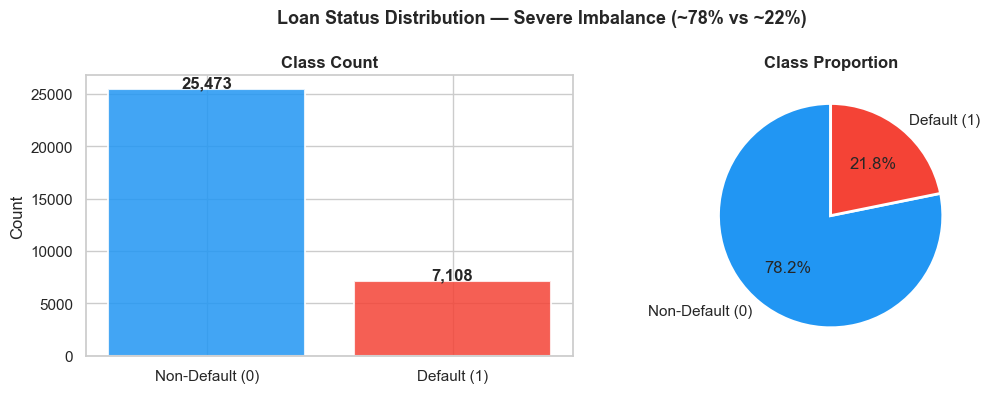

Non-Default (0): 25,473 (78.2%)
Default     (1): 7,108 (21.8%)
Imbalance ratio: 3.6:1  →  Will use SMOTE + StratifiedKFold


In [6]:
counts = df['loan_status'].value_counts().sort_index()
labels = ['Non-Default (0)', 'Default (1)']
colors = ['#2196F3', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, counts.values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Loan Status Distribution — Severe Imbalance (~78% vs ~22%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Non-Default (0): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Default     (1): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1  →  Will use SMOTE + StratifiedKFold")


### 2.2 Numerical Features — Histograms

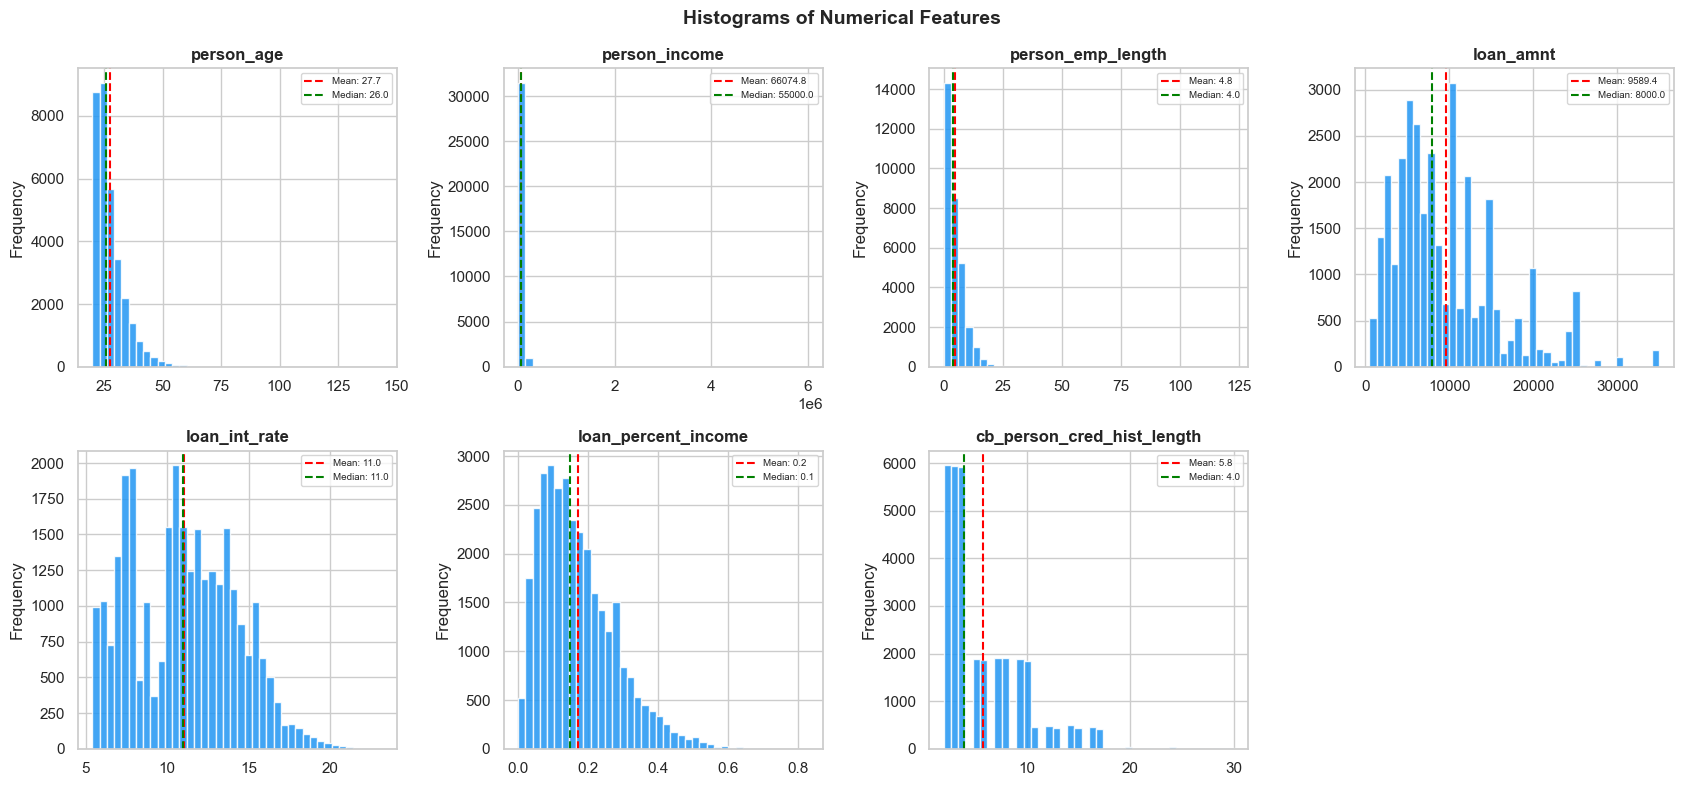

In [7]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',   linestyle='--', lw=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', lw=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

fig.delaxes(axes[7])
plt.suptitle('Histograms of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Outlier Detection — Box Plots

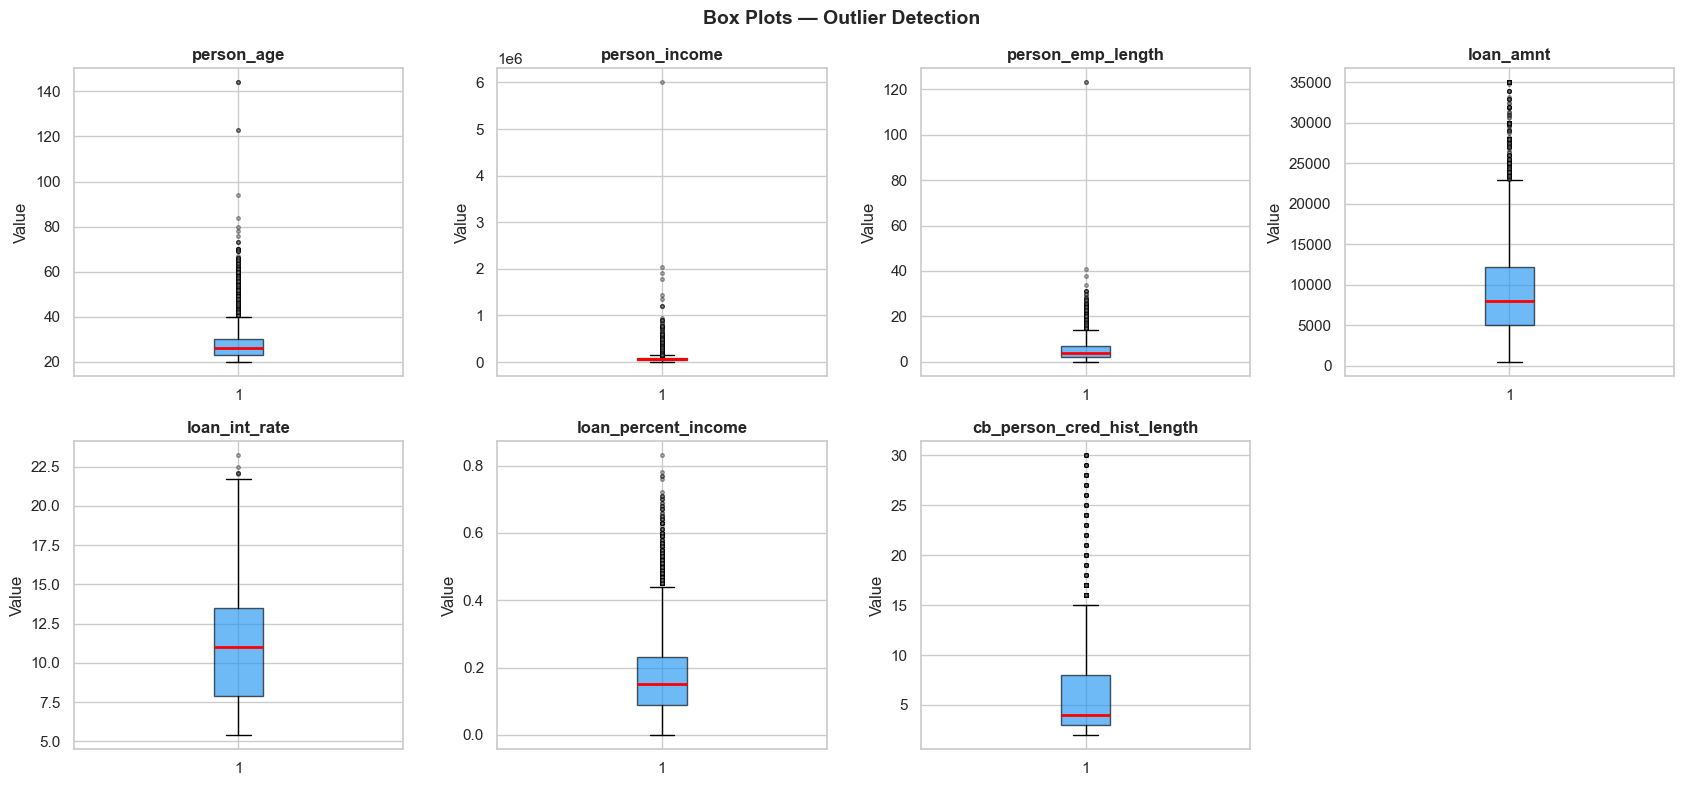

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor='#2196F3', alpha=0.65),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=2.5, alpha=0.4)
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

fig.delaxes(axes[7])
plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Outlier observations:**
- `person_age` max = **144** — biologically impossible; will drop rows where age > 100
- `person_emp_length` max = **123** — impossible; will drop rows where emp_length > 60
- `person_income` max = **6,000,000** — extreme but plausible; no removal needed (scaler handles this)


### 2.4 Categorical Features — Bar Charts

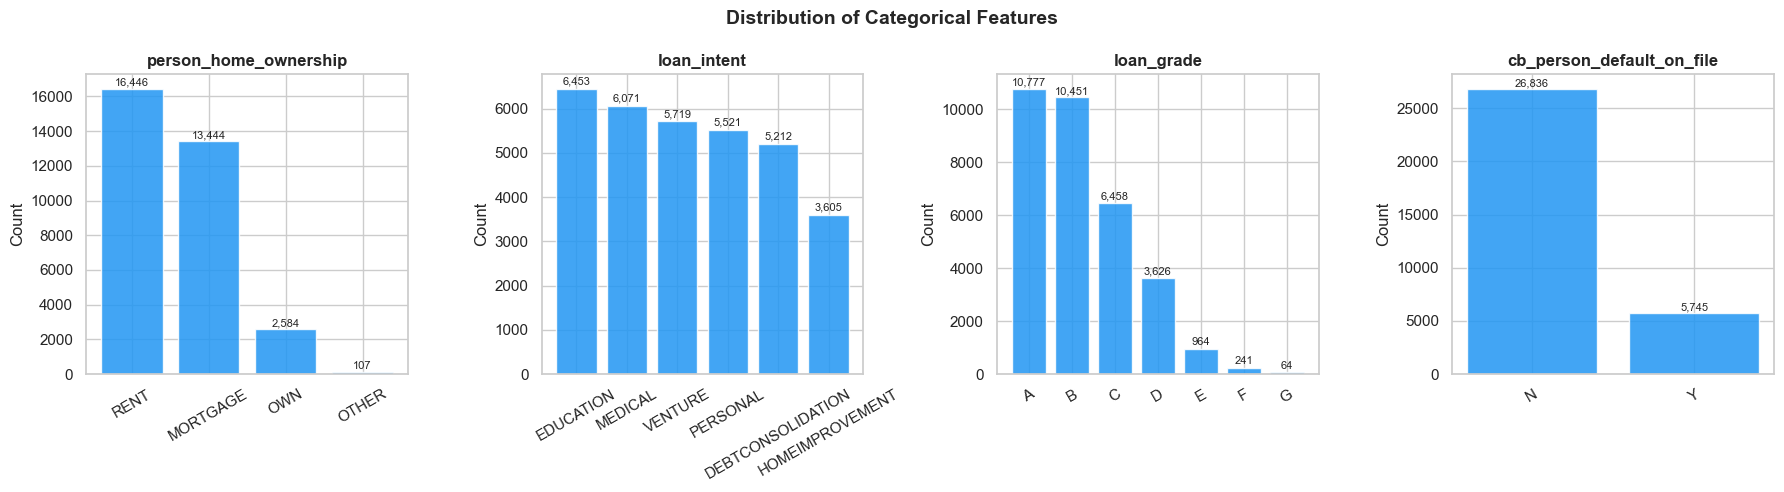

In [10]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    counts_cat = df[col].value_counts()
    bars = axes[i].bar(counts_cat.index, counts_cat.values,
                       color='#2196F3', alpha=0.85, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts_cat.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 Default Rate by Categorical Feature

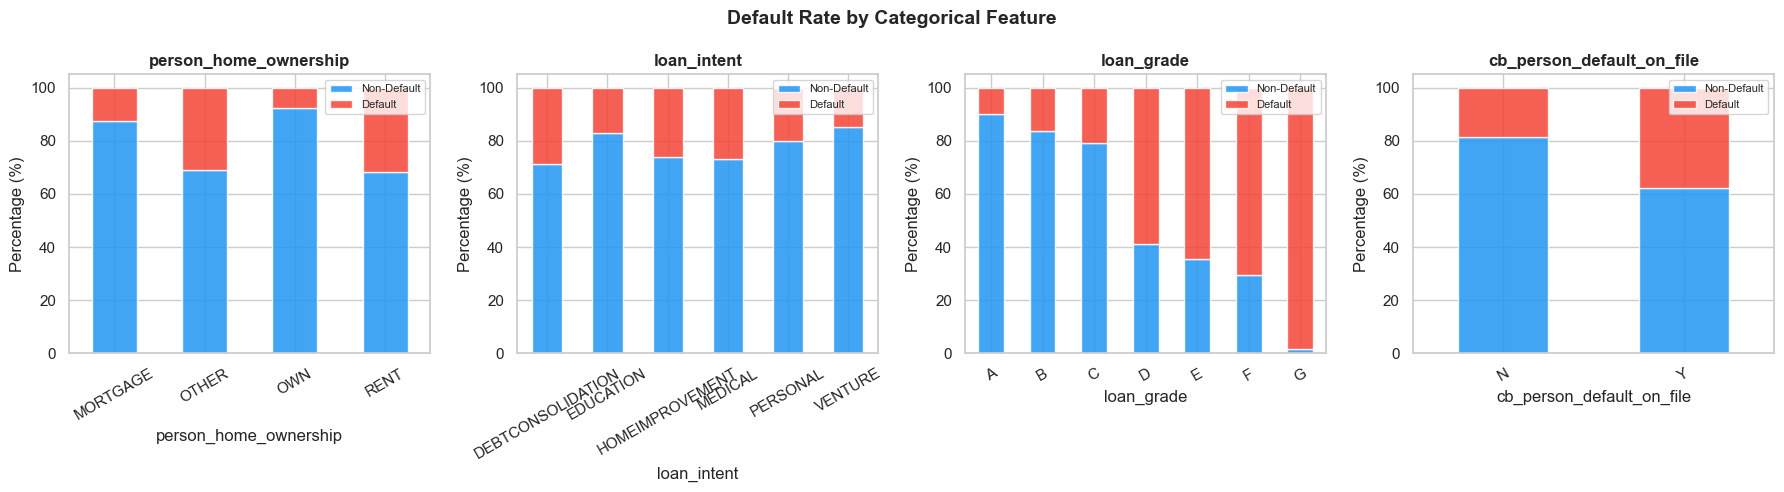

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.columns = ['Non-Default', 'Default']
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Default Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.6 Scatter Plots (colored by loan_status)

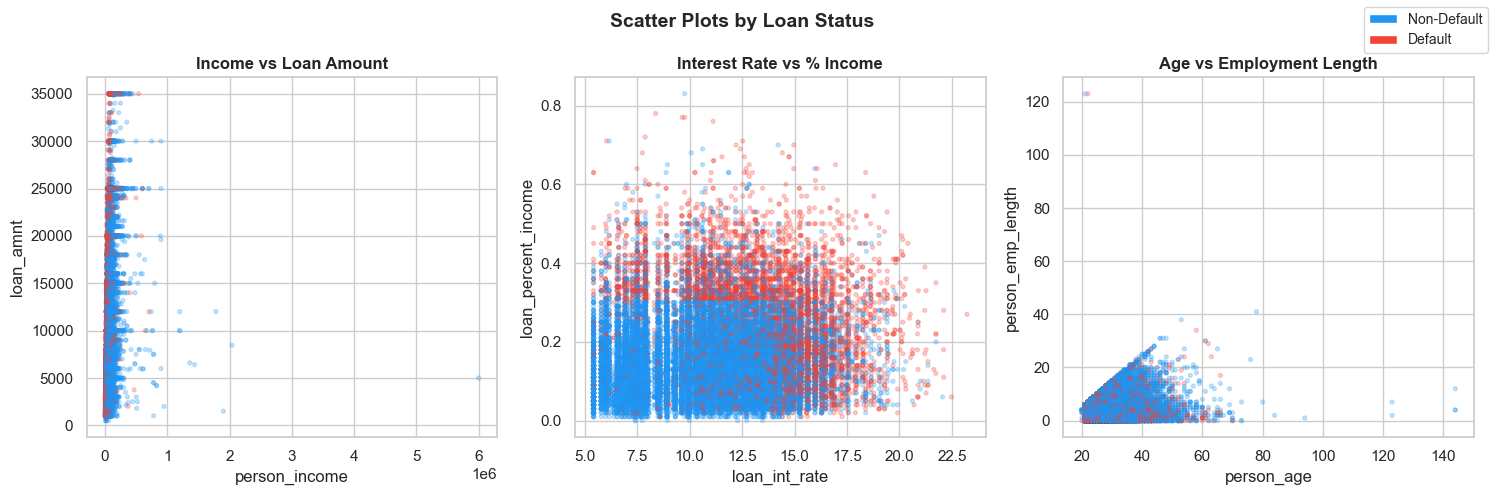

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('person_income',  'loan_amnt',           'Income vs Loan Amount'),
    ('loan_int_rate',  'loan_percent_income',  'Interest Rate vs % Income'),
    ('person_age',     'person_emp_length',    'Age vs Employment Length'),
]

colors_scatter = df['loan_status'].map({0: '#2196F3', 1: '#F44336'})

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df[x], df[y], c=colors_scatter, alpha=0.25, s=8)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontweight='bold')

legend_els = [Patch(facecolor='#2196F3', label='Non-Default'),
              Patch(facecolor='#F44336', label='Default')]
fig.legend(handles=legend_els, loc='upper right', fontsize=10)
plt.suptitle('Scatter Plots by Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.7 Correlation Heatmap

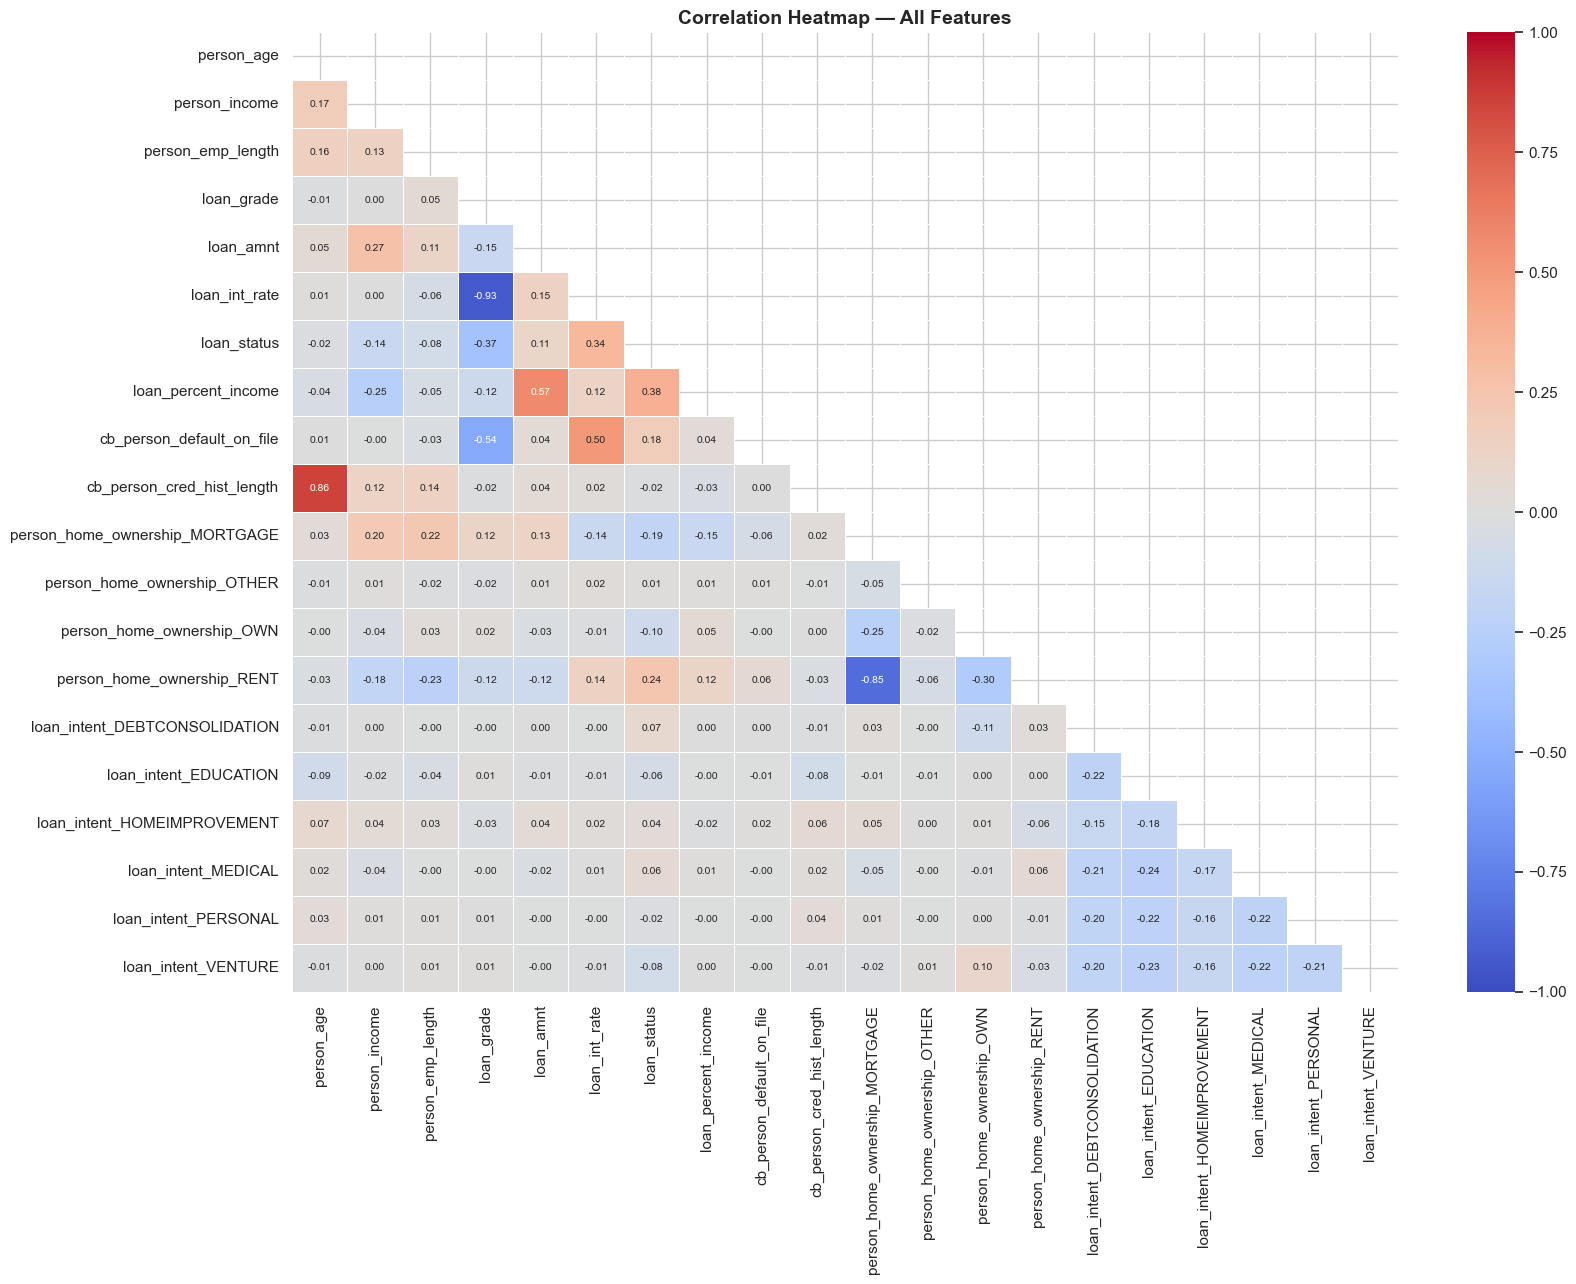

In [13]:
df_corr = df.copy()
df_corr['loan_grade']               = df_corr['loan_grade'].map({'A':6,'B':5,'C':4,'D':3,'E':2,'F':1,'G':0})
df_corr['cb_person_default_on_file'] = df_corr['cb_person_default_on_file'].map({'Y':1,'N':0})
ohe = pd.get_dummies(df_corr[['person_home_ownership','loan_intent']], dtype=float)
df_corr = pd.concat([df_corr.drop(columns=['person_home_ownership','loan_intent']), ohe], axis=1)

corr_matrix = df_corr.corr()

plt.figure(figsize=(17, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.4, annot_kws={'size': 7.5}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


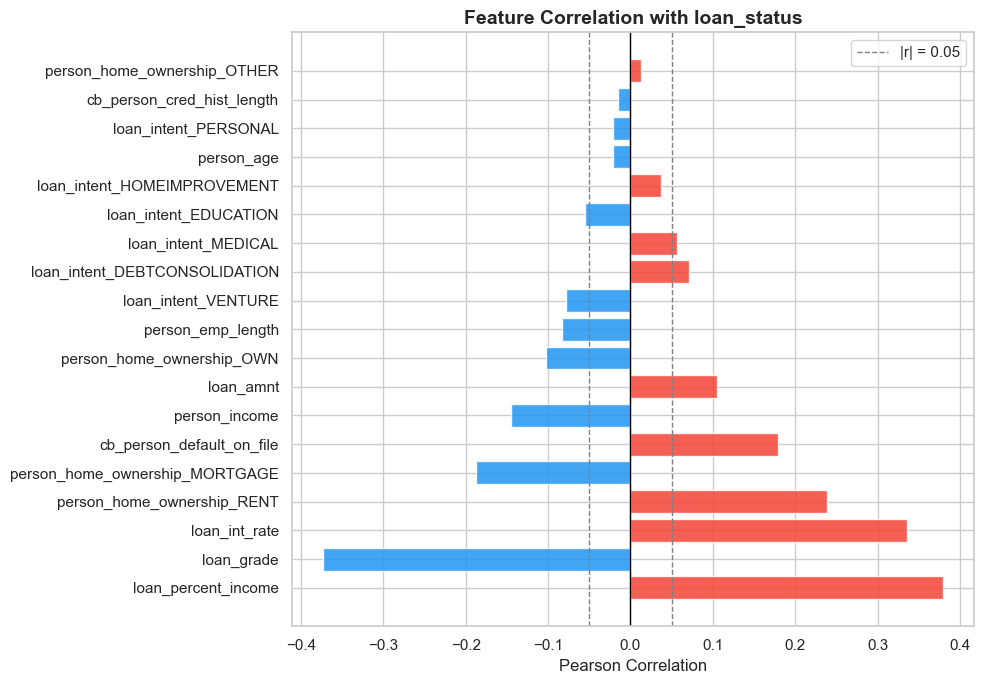

Sorted by |correlation| with loan_status:
loan_percent_income               0.379366
loan_grade                       -0.373080
loan_int_rate                     0.335133
person_home_ownership_RENT        0.238430
person_home_ownership_MORTGAGE   -0.187637
cb_person_default_on_file         0.179141
person_income                    -0.144449
loan_amnt                         0.105376
person_home_ownership_OWN        -0.101960
person_emp_length                -0.082489
loan_intent_VENTURE              -0.078274
loan_intent_DEBTCONSOLIDATION     0.071550
loan_intent_MEDICAL               0.056595
loan_intent_EDUCATION            -0.055348
loan_intent_HOMEIMPROVEMENT       0.036607
person_age                       -0.021629
loan_intent_PERSONAL             -0.021094
cb_person_cred_hist_length       -0.015529
person_home_ownership_OTHER       0.012543


In [14]:
target_corr = corr_matrix['loan_status'].drop('loan_status') \
                        .sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=bar_colors, alpha=0.85, edgecolor='white')
plt.axvline(0,    color='black', linewidth=1)
plt.axvline(0.05, color='gray',  linewidth=1, linestyle='--', label='|r| = 0.05')
plt.axvline(-0.05,color='gray',  linewidth=1, linestyle='--')
plt.title('Feature Correlation with loan_status', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.legend()
plt.tight_layout()
plt.show()

print("Sorted by |correlation| with loan_status:")
print(target_corr.to_string())


## 3. Data Preprocessing

| Step | Action | Reason |
|------|--------|--------|
| 1 | Drop `person_age > 100` and `person_emp_length > 60` | Biologically impossible — corrupt data |
| 2 | Ordinal encode `loan_grade` (A=6 … G=0) | Preserves creditworthiness ordering |
| 3 | Binary encode `cb_person_default_on_file` | Y→1, N→0 |
| 4 | One-Hot Encode `person_home_ownership`, `loan_intent` | Nominal with no ordinal meaning |
| 5 | 75/25 stratified split | Required split ratio; keeps class distribution |
| 6 | **Inside pipeline** — `SimpleImputer(median)` | Fit on train only → no leakage |
| 7 | **Inside pipeline** — `StandardScaler` | Fit on train only → no leakage |
| 8 | **Inside pipeline** — `SMOTE` | Oversample minority only during training |


In [15]:
# Step 1: remove impossible outliers (deterministic — not statistical)
df_clean = df[(df['person_age'] <= 100) & (df['person_emp_length'] <= 60)].copy()
print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"Clean dataset shape: {df_clean.shape}")

# Step 2: ordinal encode loan_grade
df_clean['loan_grade'] = df_clean['loan_grade'].map({'A':6,'B':5,'C':4,'D':3,'E':2,'F':1,'G':0})

# Step 3: binary encode
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].map({'Y':1,'N':0})

# Step 4: one-hot encode nominal categoricals
df_clean = pd.get_dummies(df_clean, columns=['person_home_ownership','loan_intent'], dtype=int)

print(f"\nFeature count after encoding: {df_clean.shape[1] - 1}")
df_clean.head(3)


Rows removed: 902
Clean dataset shape: (31679, 12)

Feature count after encoding: 19


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,5,1000,11.14,0,0.10,0,2,0,0,1,0,0,1,0,0,0,0
2,25,9600,1.0,4,5500,12.87,1,0.57,0,3,1,0,0,0,0,0,0,1,0,0
3,23,65500,4.0,4,35000,15.23,1,0.53,0,2,0,0,0,1,0,0,0,1,0,0


In [16]:
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train):,} rows ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test):,} rows  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain class ratio → 0: {(y_train==0).mean()*100:.1f}%  1: {(y_train==1).mean()*100:.1f}%")
print(f"Test  class ratio → 0: {(y_test==0).mean()*100:.1f}%  1: {(y_test==1).mean()*100:.1f}%")


Train: 23,759 rows (75.0%)
Test:  7,920 rows  (25.0%)

Train class ratio → 0: 78.5%  1: 21.5%
Test  class ratio → 0: 78.5%  1: 21.5%


## 4. Model Training

Each model uses an **imblearn Pipeline**:
```
SimpleImputer(median) → StandardScaler → SMOTE → Model
```
- `SimpleImputer` + `StandardScaler` are fit **only on training folds** (no leakage)
- `SMOTE` is applied **only during training** (not during evaluation)
- `GridSearchCV` with `StratifiedKFold(n_splits=5)` for hyperparameter tuning
- Primary metric: **ROC-AUC** (robust to class imbalance)


In [17]:
results = {}

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_aucs = []

    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        X_cv_tr, X_cv_val = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        y_cv_tr, y_cv_val = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        pipeline.fit(X_cv_tr, y_cv_tr)
        if hasattr(pipeline, 'predict_proba'):
            scores = pipeline.predict_proba(X_cv_val)[:, 1]
        else:
            scores = pipeline.decision_function(X_cv_val)
        cv_aucs.append(roc_auc_score(y_cv_val, scores))

    print(f"  CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    if hasattr(pipeline, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_te)[:, 1]
    else:
        y_proba = pipeline.decision_function(X_te)

    test_auc = roc_auc_score(y_te, y_proba)
    f1_mac   = f1_score(y_te, y_pred, average='macro')

    print(f"\n{'='*50}")
    print(f"  {name} — Test Results")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Non-Default','Default']))
    print(f"  Test AUC : {test_auc:.4f}")
    print(f"  F1 Macro : {f1_mac:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Non-Default','Default']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix — {name}', fontweight='bold')
    RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1], name=name, color='#2196F3')
    axes[1].plot([0,1],[0,1],'k--', alpha=0.5)
    axes[1].set_title(f'ROC Curve — {name}  (AUC={test_auc:.4f})', fontweight='bold')
    plt.tight_layout()
    plt.show()

    results[name] = {
        'CV AUC (mean)': np.mean(cv_aucs),
        'CV AUC (std)':  np.std(cv_aucs),
        'Test AUC':      test_auc,
        'F1 Macro':      f1_mac,
        'pipeline':      pipeline
    }


### 4.1 Support Vector Classifier (SVC)

In [18]:
svc_base = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('svc',     SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
])

svc_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 'auto']}

svc_gs = GridSearchCV(
    svc_base, svc_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
svc_gs.fit(X_train, y_train)
print(f"Best params : {svc_gs.best_params_}")
print(f"Best CV AUC : {svc_gs.best_score_:.4f}")


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params : {'svc__C': 1, 'svc__gamma': 'scale'}
Best CV AUC : 0.9039


  CV AUC: 0.9042 ± 0.0043

  SVC — Test Results
              precision    recall  f1-score   support

 Non-Default       0.93      0.92      0.92      6214
     Default       0.71      0.76      0.73      1706

    accuracy                           0.88      7920
   macro avg       0.82      0.84      0.83      7920
weighted avg       0.88      0.88      0.88      7920

  Test AUC : 0.9059
  F1 Macro : 0.8290


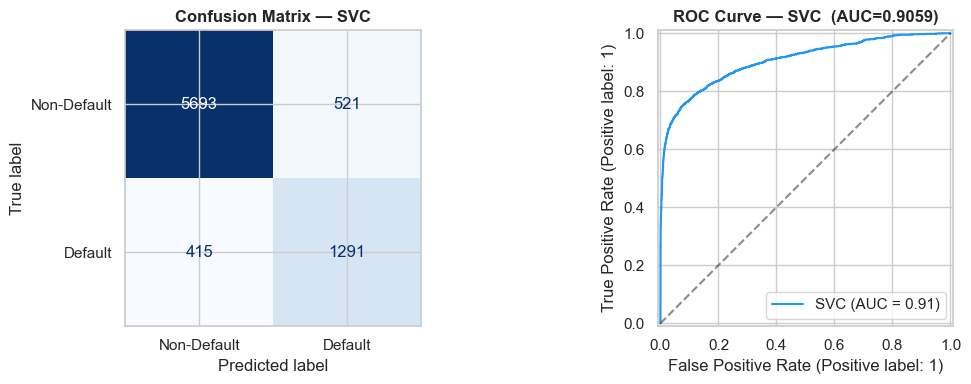

In [19]:
evaluate_model('SVC', svc_gs.best_estimator_, X_train, y_train, X_test, y_test)

### 4.2 Logistic Regression

In [20]:
lr_base = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('lr',      LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_grid = {
    'lr__C':            [0.01, 0.1, 1, 10, 100],
    'lr__class_weight': [None, 'balanced'],
    'lr__solver':       ['lbfgs', 'liblinear']
}

lr_gs = GridSearchCV(
    lr_base, lr_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
lr_gs.fit(X_train, y_train)
print(f"Best params : {lr_gs.best_params_}")
print(f"Best CV AUC : {lr_gs.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'lr__C': 0.01, 'lr__class_weight': None, 'lr__solver': 'liblinear'}
Best CV AUC : 0.8639


  CV AUC: 0.8639 ± 0.0025

  Logistic Regression — Test Results
              precision    recall  f1-score   support

 Non-Default       0.93      0.79      0.85      6214
     Default       0.50      0.79      0.61      1706

    accuracy                           0.79      7920
   macro avg       0.72      0.79      0.73      7920
weighted avg       0.84      0.79      0.80      7920

  Test AUC : 0.8673
  F1 Macro : 0.7329


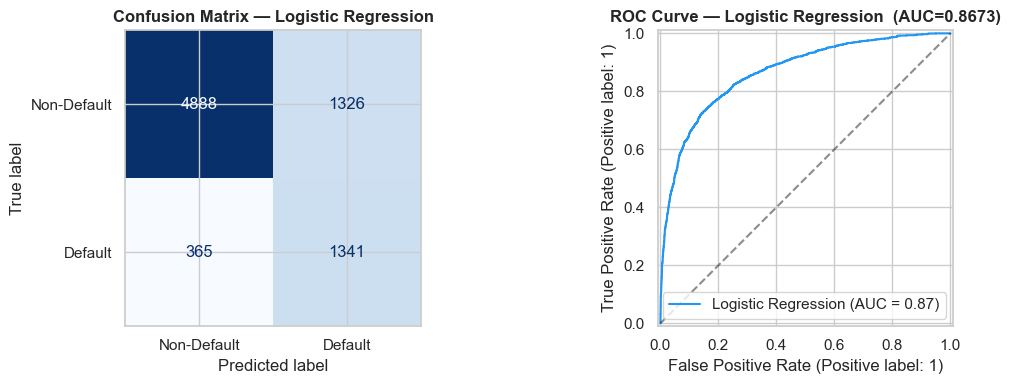

In [21]:
evaluate_model('Logistic Regression', lr_gs.best_estimator_, X_train, y_train, X_test, y_test)

### 4.3 Random Forest

In [22]:
rf_base = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('rf',      RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth':    [10, 20, None],
    'rf__class_weight': [None, 'balanced']
}

rf_gs = GridSearchCV(
    rf_base, rf_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_gs.fit(X_train, y_train)
print(f"Best params : {rf_gs.best_params_}")
print(f"Best CV AUC : {rf_gs.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'rf__class_weight': None, 'rf__max_depth': 20, 'rf__n_estimators': 200}
Best CV AUC : 0.9302


  CV AUC: 0.9302 ± 0.0032

  Random Forest — Test Results
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      6214
     Default       0.94      0.73      0.82      1706

    accuracy                           0.93      7920
   macro avg       0.93      0.86      0.89      7920
weighted avg       0.93      0.93      0.93      7920

  Test AUC : 0.9332
  F1 Macro : 0.8888


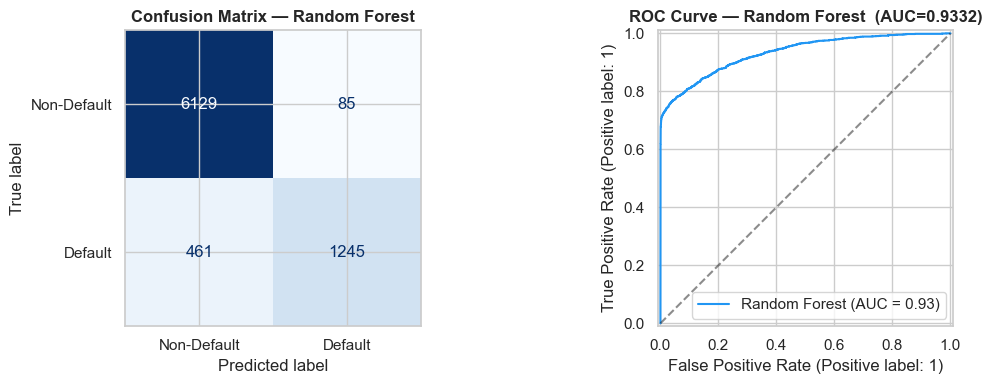

In [23]:
evaluate_model('Random Forest', rf_gs.best_estimator_, X_train, y_train, X_test, y_test)

### 4.4 Gradient Boosting

In [24]:
gb_base = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('gb',      GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_grid = {
    'gb__n_estimators':  [100, 200],
    'gb__max_depth':     [3, 5],
    'gb__learning_rate': [0.05, 0.1, 0.2]
}

gb_gs = GridSearchCV(
    gb_base, gb_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
gb_gs.fit(X_train, y_train)
print(f"Best params : {gb_gs.best_params_}")
print(f"Best CV AUC : {gb_gs.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'gb__learning_rate': 0.2, 'gb__max_depth': 5, 'gb__n_estimators': 200}
Best CV AUC : 0.9458


  CV AUC: 0.9464 ± 0.0016

  Gradient Boosting — Test Results
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      6214
     Default       0.96      0.74      0.83      1706

    accuracy                           0.94      7920
   macro avg       0.94      0.87      0.90      7920
weighted avg       0.94      0.94      0.93      7920

  Test AUC : 0.9488
  F1 Macro : 0.8977


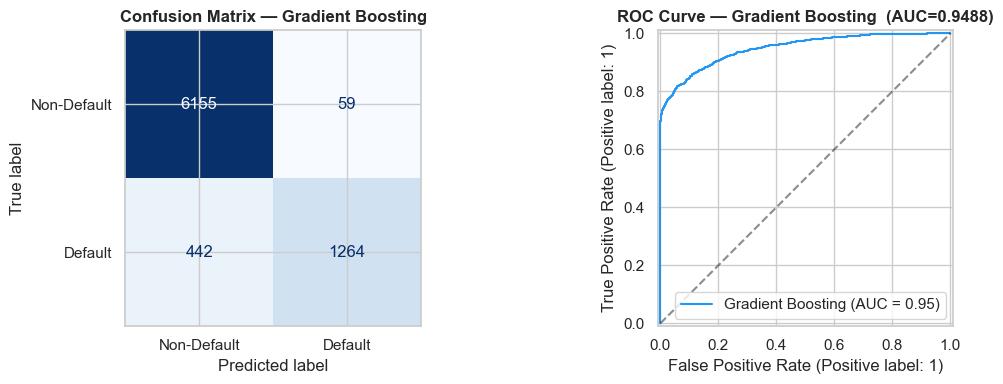

In [25]:
evaluate_model('Gradient Boosting', gb_gs.best_estimator_, X_train, y_train, X_test, y_test)

### 4.5 XGBoost

In [26]:
xgb_base = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('xgb',     xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='auc', verbosity=0))
])

xgb_grid = {
    'xgb__n_estimators':  [100, 200],
    'xgb__max_depth':     [3, 6],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample':     [0.8, 1.0]
}

xgb_gs = GridSearchCV(
    xgb_base, xgb_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train, y_train)
print(f"Best params : {xgb_gs.best_params_}")
print(f"Best CV AUC : {xgb_gs.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
Best CV AUC : 0.9402


  CV AUC: 0.9401 ± 0.0018

  XGBoost — Test Results
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      6214
     Default       0.97      0.73      0.83      1706

    accuracy                           0.94      7920
   macro avg       0.95      0.86      0.90      7920
weighted avg       0.94      0.94      0.93      7920

  Test AUC : 0.9442
  F1 Macro : 0.8965


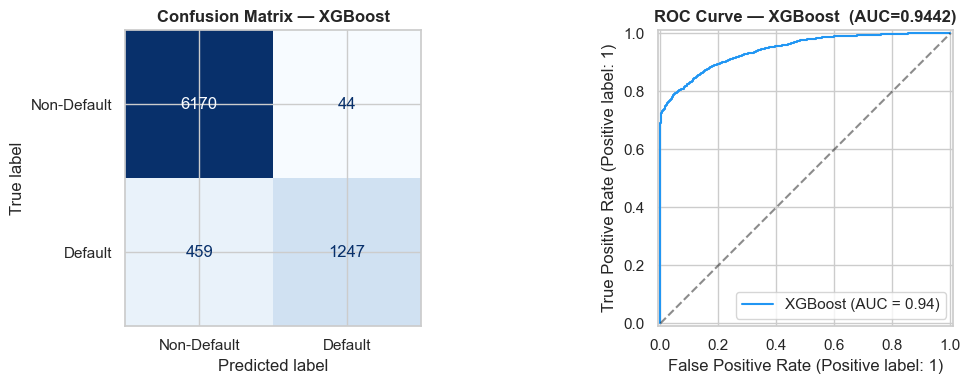

In [27]:
evaluate_model('XGBoost', xgb_gs.best_estimator_, X_train, y_train, X_test, y_test)

### 4.6 LightGBM

In [28]:
lgb_base = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('lgb',     lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1))
])

lgb_grid = {
    'lgb__n_estimators':  [100, 200],
    'lgb__max_depth':     [5, 10],
    'lgb__learning_rate': [0.05, 0.1],
    'lgb__num_leaves':    [31, 63]
}

lgb_gs = GridSearchCV(
    lgb_base, lgb_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
lgb_gs.fit(X_train, y_train)
print(f"Best params : {lgb_gs.best_params_}")
print(f"Best CV AUC : {lgb_gs.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'lgb__learning_rate': 0.1, 'lgb__max_depth': 10, 'lgb__n_estimators': 200, 'lgb__num_leaves': 63}
Best CV AUC : 0.9424


  CV AUC: 0.9423 ± 0.0017

  LightGBM — Test Results
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      6214
     Default       0.95      0.74      0.83      1706

    accuracy                           0.94      7920
   macro avg       0.94      0.87      0.90      7920
weighted avg       0.94      0.94      0.93      7920

  Test AUC : 0.9479
  F1 Macro : 0.8976


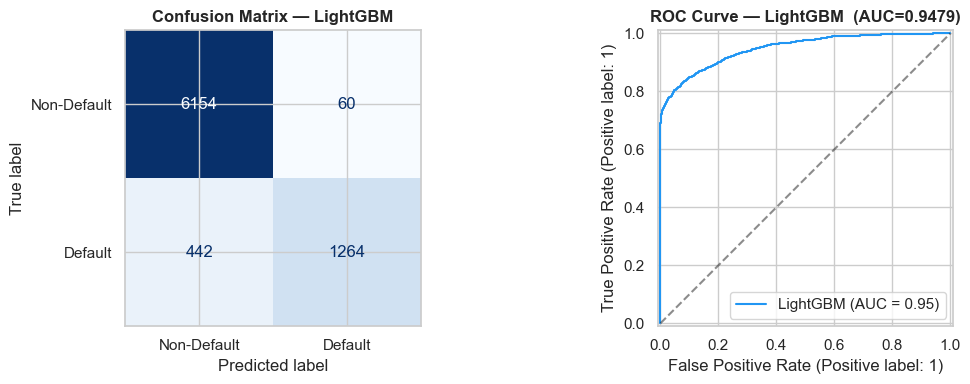

In [29]:
evaluate_model('LightGBM', lgb_gs.best_estimator_, X_train, y_train, X_test, y_test)

## 5. Model Comparison

In [30]:
summary = {
    name: {
        'CV AUC': f"{m['CV AUC (mean)']:.4f} ± {m['CV AUC (std)']:.4f}",
        'Test AUC': round(m['Test AUC'], 4),
        'F1 Macro': round(m['F1 Macro'], 4)
    }
    for name, m in results.items()
}
comparison_df = pd.DataFrame(summary).T.sort_values('Test AUC', ascending=False)
print("=" * 58)
print("  MODEL COMPARISON SUMMARY")
print("=" * 58)
print(comparison_df.to_string())


  MODEL COMPARISON SUMMARY
                              CV AUC Test AUC F1 Macro
Gradient Boosting    0.9464 ± 0.0016   0.9488   0.8977
LightGBM             0.9423 ± 0.0017   0.9479   0.8976
XGBoost              0.9401 ± 0.0018   0.9442   0.8965
Random Forest        0.9302 ± 0.0032   0.9332   0.8888
SVC                  0.9042 ± 0.0043   0.9059    0.829
Logistic Regression  0.8639 ± 0.0025   0.8673   0.7329


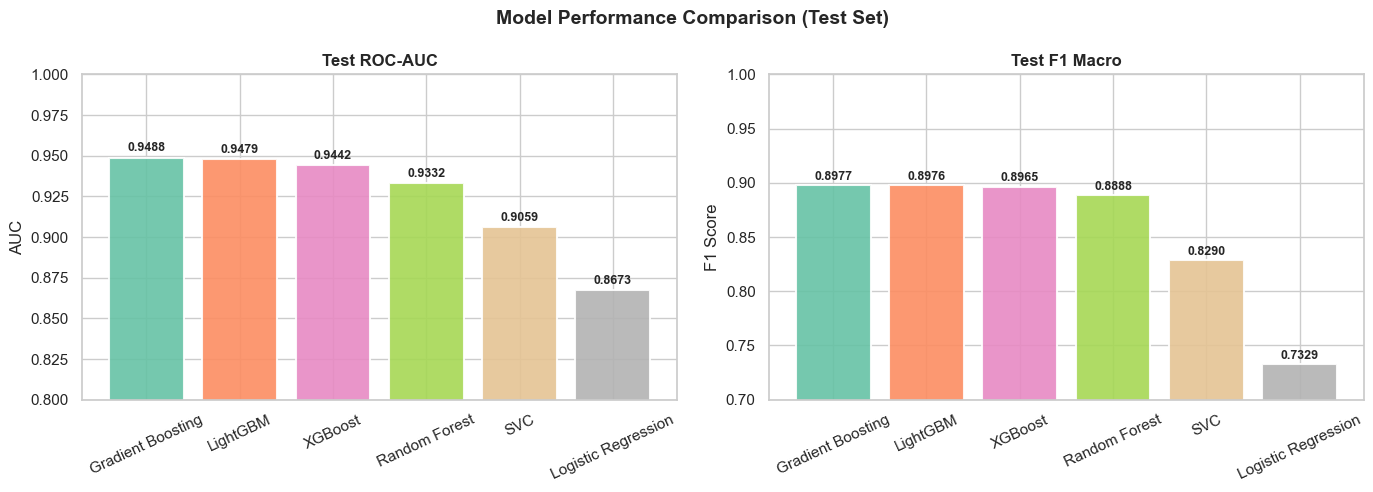


>>> Best Model : Gradient Boosting
    Test AUC   : 0.9488
    F1 Macro   : 0.8977


In [31]:
model_names  = list(comparison_df.index)
test_aucs    = [results[m]['Test AUC'] for m in model_names]
f1_macros    = [results[m]['F1 Macro'] for m in model_names]
palette      = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, ylabel, ylim, title in [
    (axes[0], test_aucs, 'AUC',      (0.80, 1.00), 'Test ROC-AUC'),
    (axes[1], f1_macros, 'F1 Score', (0.70, 1.00), 'Test F1 Macro'),
]:
    bars = ax.bar(model_names, values, color=palette, alpha=0.9, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_name = comparison_df.index[0]
print(f"\n>>> Best Model : {best_name}")
print(f"    Test AUC   : {results[best_name]['Test AUC']:.4f}")
print(f"    F1 Macro   : {results[best_name]['F1 Macro']:.4f}")


## 6. ROC Curve Overlay — All Models

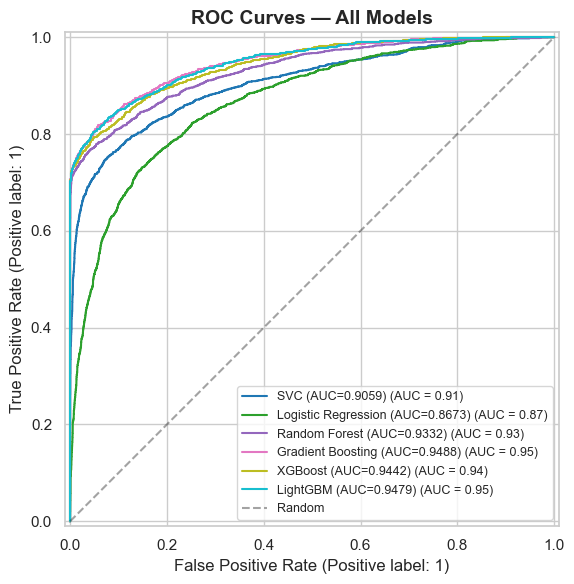

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
palette_roc = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, m), color in zip(results.items(), palette_roc):
    pipe = m['pipeline']
    pipe.fit(X_train, y_train)
    if hasattr(pipe, 'predict_proba'):
        y_proba_roc = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba_roc = pipe.decision_function(X_test)
    RocCurveDisplay.from_predictions(
        y_test, y_proba_roc, ax=ax,
        name=f"{name} (AUC={m['Test AUC']:.4f})", color=color
    )

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Save Best Model

In [33]:
best_pipeline = results[best_name]['pipeline']
best_pipeline.fit(X_train, y_train)   # ensure fitted on full train set

filename = f"best_model_{best_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_pipeline, filename)
print(f"Saved: {filename}")
print(f"Model: {best_name}")
print(f"Test AUC: {results[best_name]['Test AUC']:.4f}")


Saved: best_model_gradient_boosting.pkl
Model: Gradient Boosting
Test AUC: 0.9488
